In [1]:
# Milestone 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('data/heart_disease_uci.csv')
print('=' * 60)
print('HEART DISEASE UCI - FULL PIPELINE')
print('=' * 60)
print(f'\n[1] Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print('\n[2] Column Data Types:')
print(df.dtypes.to_string())
print('\n[3] First 5 Rows:')
df.head()

HEART DISEASE UCI - FULL PIPELINE

[1] Dataset Shape: 920 rows x 16 columns

[2] Column Data Types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64

[3] First 5 Rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
print('[4] Missing Values (count & %):')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].to_string())

print('\n[5] Descriptive Statistics (numeric):')
print(df.describe().to_string())

print('\n[6] Target Variable Distribution (num):')
print(df['num'].value_counts().to_string())

print('\n[7] Categorical Unique Values:')
cat_cols = ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal']
for col in cat_cols:
    print(f'  {col}: {df[col].dropna().unique().tolist()}')

print('\n[8] Duplicate Rows:', df.duplicated().sum())

[4] Missing Values (count & %):
          Missing Count  Missing %
trestbps             59       6.41
chol                 30       3.26
fbs                  90       9.78
restecg               2       0.22
thalch               55       5.98
exang                55       5.98
oldpeak              62       6.74
slope               309      33.59
ca                  611      66.41
thal                486      52.83

[5] Descriptive Statistics (numeric):
               id         age    trestbps        chol      thalch     oldpeak          ca         num
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000  309.000000  920.000000
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788    0.676375    0.995652
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226    0.935653    1.142693
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000    0.000000    0.000000
25%    230.750000   47.000000  120

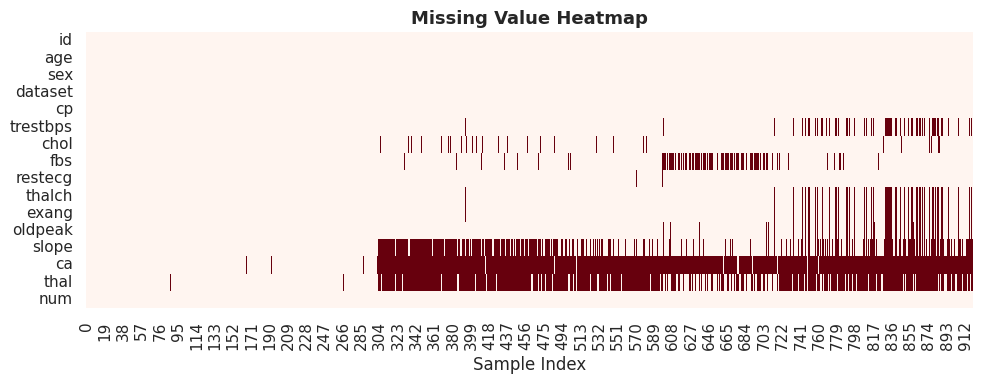

In [4]:
# Fig 1: Missing Value Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=df.columns, cmap='Reds', ax=ax)
ax.set_title('Missing Value Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index')
plt.tight_layout()
plt.savefig('eda_missing_heatmap.png', dpi=150)
plt.show()

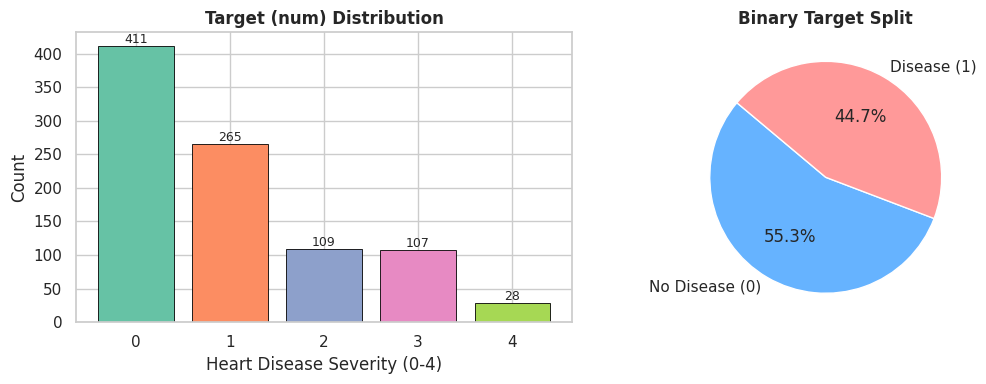

In [5]:
# Fig 2: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
val_counts = df['num'].value_counts().sort_index()
colors = sns.color_palette('Set2', 5)
axes[0].bar(val_counts.index, val_counts.values, color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('Target (num) Distribution', fontweight='bold')
axes[0].set_xlabel('Heart Disease Severity (0-4)')
axes[0].set_ylabel('Count')
for i, v in zip(val_counts.index, val_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

binary = df['num'].apply(lambda x: 0 if x == 0 else 1)
bc = binary.value_counts()
axes[1].pie(bc, labels=['No Disease (0)', 'Disease (1)'], autopct='%1.1f%%',
            colors=['#66b3ff', '#ff9999'], startangle=140)
axes[1].set_title('Binary Target Split', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150)
plt.show()

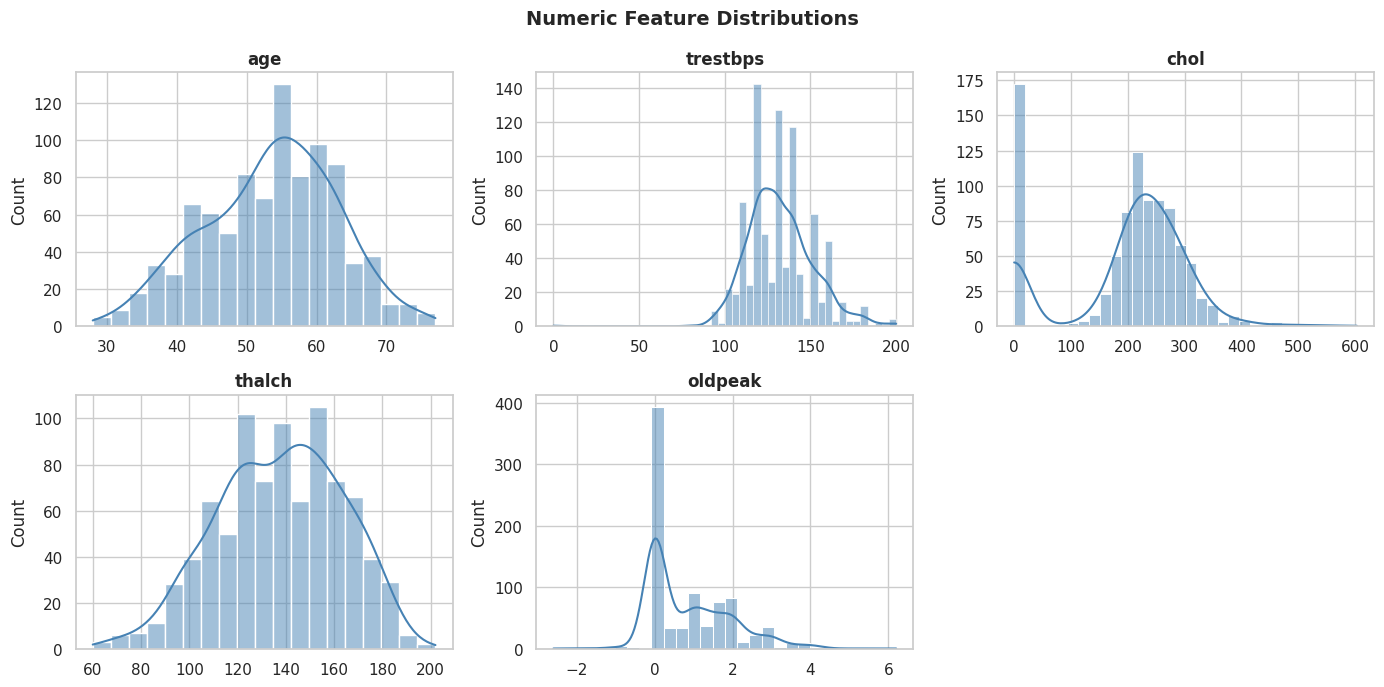

In [6]:
# Fig 3: Numeric Feature Distributions
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
axes[-1].set_visible(False)
fig.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numeric_distributions.png', dpi=150)
plt.show()

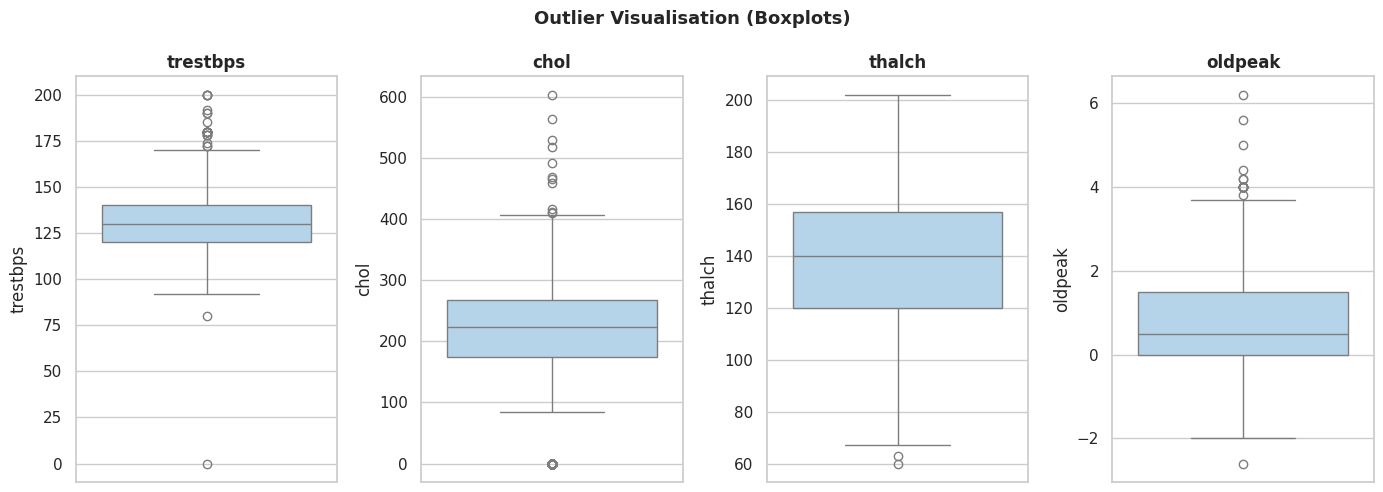

In [7]:
# Fig 4: Boxplots for Outlier Visualisation
outlier_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='#AED6F1')
    axes[i].set_title(col, fontweight='bold')
fig.suptitle('Outlier Visualisation (Boxplots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150)
plt.show()

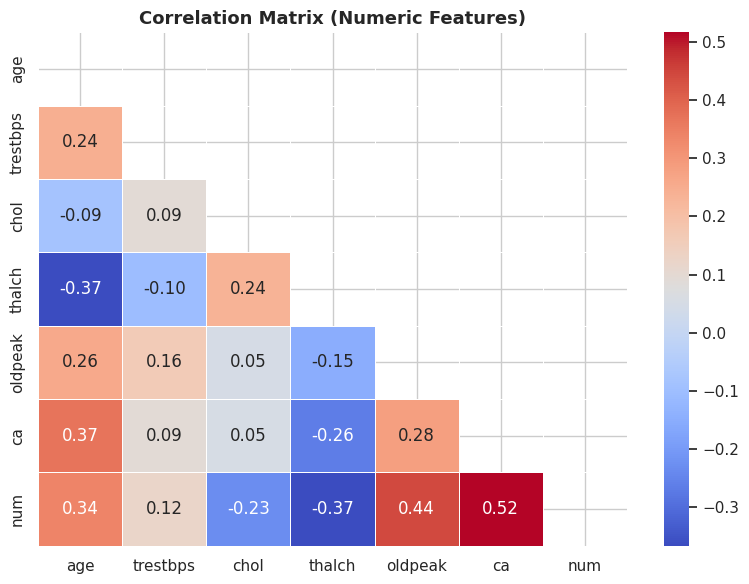

In [8]:
# Fig 5: Correlation Heatmap
# Using pairwise correlation (min_periods=1) to avoid dropping rows
# due to missing values in 'ca'
num_df = df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']]
corr_matrix = num_df.corr(min_periods=1)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150)
plt.show()

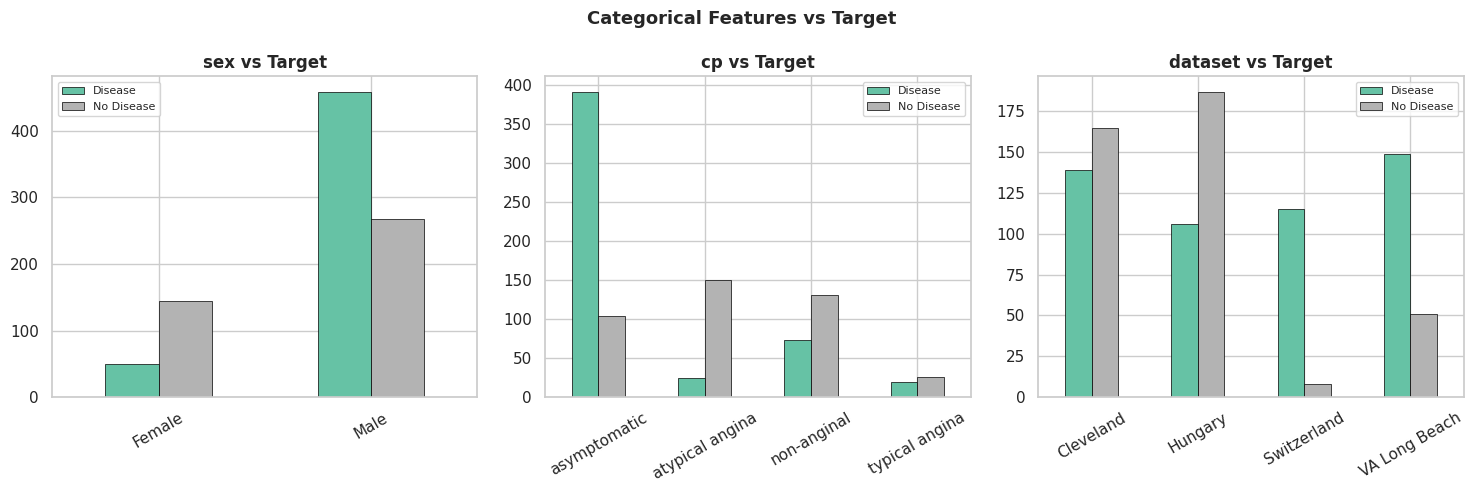

EDA complete.


In [9]:
# Fig 6: Categorical Features vs Target
cat_cols_plot = ['sex', 'cp', 'dataset']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(cat_cols_plot):
    ct = pd.crosstab(df[col], df['num'].apply(lambda x: 'Disease' if x > 0 else 'No Disease'))
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='black', linewidth=0.5, rot=30)
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)
fig.suptitle('Categorical Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical_vs_target.png', dpi=150)
plt.show()

print('EDA complete.')

In [10]:
# Step 1: Drop irrelevant column & create binary target
df_clean = df.copy()
df_clean.drop(columns=['id'], inplace=True)
df_clean['target'] = df_clean['num'].apply(lambda x: 0 if x == 0 else 1)
df_clean.drop(columns=['num'], inplace=True)

print(f'Shape after drop: {df_clean.shape}')
print(f'Target — 0 (No Disease): {(df_clean["target"]==0).sum()}, 1 (Disease): {(df_clean["target"]==1).sum()}')

Shape after drop: (920, 15)
Target — 0 (No Disease): 411, 1 (Disease): 509


In [11]:
# Step 2: Encode categoricals (no leakage risk for encoding structure)
ohe_cols = ['cp', 'restecg', 'slope', 'thal']
df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=False)

df_clean['sex']     = df_clean['sex'].map({'Male': 1, 'Female': 0})
df_clean['dataset'] = df_clean['dataset'].astype('category').cat.codes

for col in ['fbs', 'exang']:
    df_clean[col] = df_clean[col].map({True: 1, False: 0, 'True': 1, 'False': 0})

print(f'Shape after encoding: {df_clean.shape}')

Shape after encoding: (920, 24)


In [12]:
# Step 3: Train / Test split FIRST (stratified 80/20)
X = df_clean.drop(columns=['target'])
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance:  {y_test.value_counts().to_dict()}')

Train: 736 samples | Test: 184 samples
Train class balance: {1: 407, 0: 329}
Test class balance:  {1: 102, 0: 82}


In [13]:
# Step 4: Impute missing values (fit on TRAIN only, apply to both)
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
bool_cols    = ['fbs', 'exang']

train_medians = X_train[numeric_cols].median()
train_modes   = X_train[bool_cols].mode().iloc[0]

X_train[numeric_cols] = X_train[numeric_cols].fillna(train_medians)
X_test[numeric_cols]  = X_test[numeric_cols].fillna(train_medians)
X_train[bool_cols]    = X_train[bool_cols].fillna(train_modes)
X_test[bool_cols]     = X_test[bool_cols].fillna(train_modes)

print(f'Remaining missing — Train: {X_train.isnull().sum().sum()}, Test: {X_test.isnull().sum().sum()}')

Remaining missing — Train: 0, Test: 0


In [14]:
# Step 5: Outlier capping via IQR (fit on TRAIN only, apply to both)
outlier_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in outlier_cols:
    Q1    = X_train[col].quantile(0.25)
    Q3    = X_train[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col]  = X_test[col].clip(lower=lower, upper=upper)
    print(f'  {col}: capped [{lower:.2f}, {upper:.2f}]')

  trestbps: capped [90.00, 170.00]
  chol: capped [43.12, 400.12]
  thalch: capped [67.50, 207.50]
  oldpeak: capped [-2.25, 3.75]


In [15]:
# Step 6: Feature scaling (fit on TRAIN only, apply to both)
scale_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f'Scaling applied. Final feature count: {X_train.shape[1]}')

Scaling applied. Final feature count: 23


In [16]:
# Step 7: Save processed data
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

print('Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv')
print('Milestone 1 complete.')

Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv
Milestone 1 complete.


In [17]:
# Milestone 3 (Model Chosen: Random Forest)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

In [18]:
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print(f'Train: {X_train.shape[0]} samples')
print(f'Number of trees   : {rf_model.n_estimators}')
print(f'Number of features: {rf_model.n_features_in_}')

Train: 736 samples
Number of trees   : 100
Number of features: 23


In [19]:
# Training vs Test Performance

y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

metrics = {
    'Set'       : ['Train', 'Test'],
    'Accuracy'  : [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
    'F1 Score'  : [f1_score(y_train, y_train_pred),       f1_score(y_test, y_test_pred)],
    'Precision' : [precision_score(y_train, y_train_pred), precision_score(y_test, y_test_pred)],
    'Recall'    : [recall_score(y_train, y_train_pred),   recall_score(y_test, y_test_pred)]
}

metrics_df = pd.DataFrame(metrics).set_index('Set')
print(' Train vs Test Metrics ')
print(metrics_df.round(4).to_string())

 Train vs Test Metrics 
       Accuracy  F1 Score  Precision  Recall
Set                                         
Train    1.0000     1.000      1.000   1.000
Test     0.8533     0.872      0.844   0.902


In [20]:
# Cross Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_f1       = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='f1')

print(' 5-Fold Cross-Validation Results ')
print(f'Accuracy per fold : {cv_accuracy.round(4)}')
print(f'Mean Accuracy     : {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}')
print(f'\nF1 per fold       : {cv_f1.round(4)}')
print(f'Mean F1 Score     : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')

 5-Fold Cross-Validation Results 
Accuracy per fold : [0.8041 0.8095 0.8095 0.8231 0.8435]
Mean Accuracy     : 0.8180 +/- 0.0143

F1 per fold       : [0.8343 0.8391 0.825  0.8395 0.8553]
Mean F1 Score     : 0.8386 +/- 0.0098


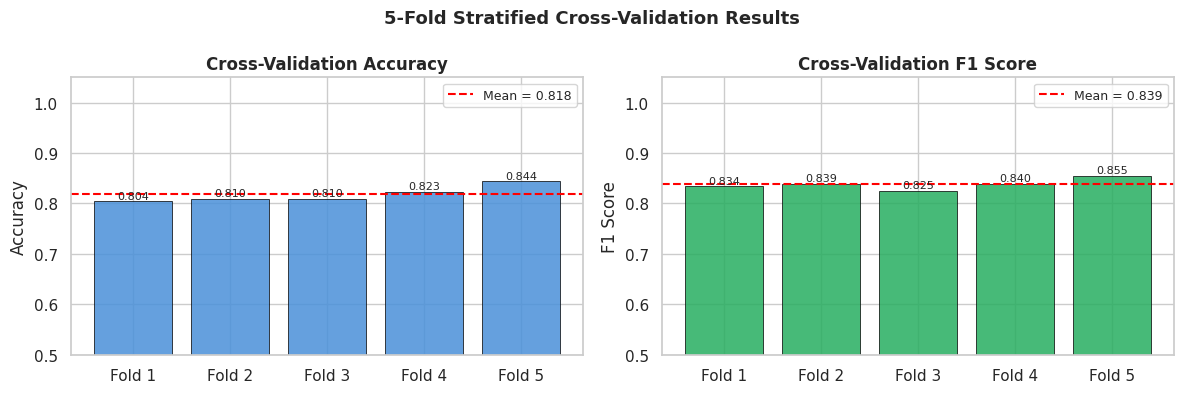

In [21]:
# CV Results Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
folds = [f'Fold {i+1}' for i in range(5)]

for ax, scores, label, color in zip(
    axes,
    [cv_accuracy, cv_f1],
    ['Accuracy', 'F1 Score'],
    ['#4A90D9', '#27AE60']
):
    bars = ax.bar(folds, scores, color=color, edgecolor='black', linewidth=0.6, alpha=0.85)
    ax.axhline(scores.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean = {scores.mean():.3f}')
    ax.set_ylim(0.5, 1.05)
    ax.set_title(f'Cross-Validation {label}', fontweight='bold')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8)

fig.suptitle('5-Fold Stratified Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('m3_cv_results.png', dpi=150)
plt.show()

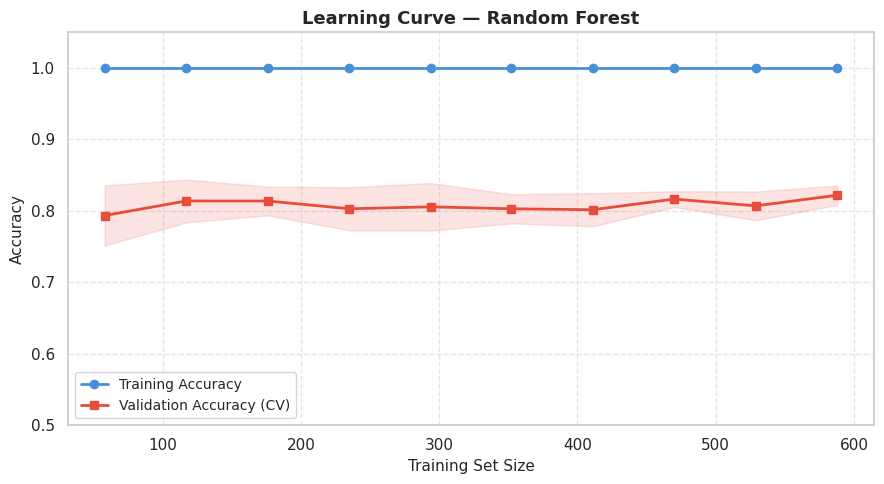

In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train, y_train,
    cv=cv,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4A90D9', label='Training Accuracy', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#4A90D9')
ax.plot(train_sizes, val_mean, 's-', color='#E74C3C', label='Validation Accuracy (CV)', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#E74C3C')

ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Learning Curve — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m3_learning_curve.png', dpi=150)
plt.show()

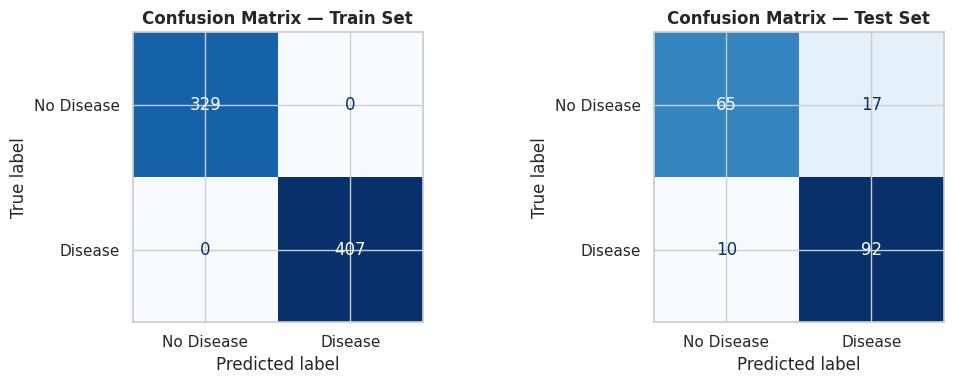

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_test],
    [y_train_pred, y_test_pred],
    ['Confusion Matrix — Train Set', 'Confusion Matrix — Test Set']
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Disease', 'Disease']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('m3_confusion_matrix.png', dpi=150)
plt.show()

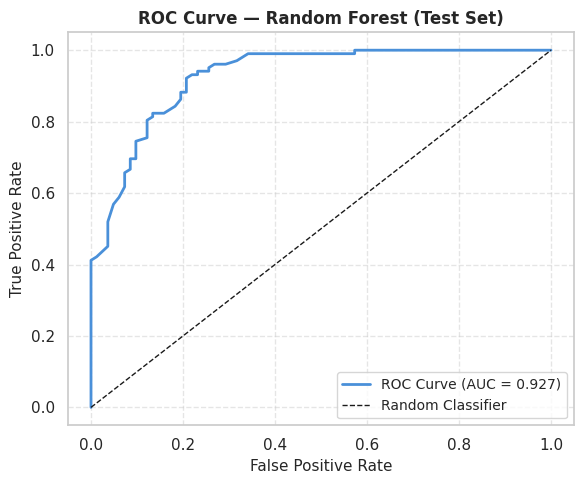

In [24]:
y_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#4A90D9', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Random Forest (Test Set)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m3_roc_curve.png', dpi=150)
plt.show()

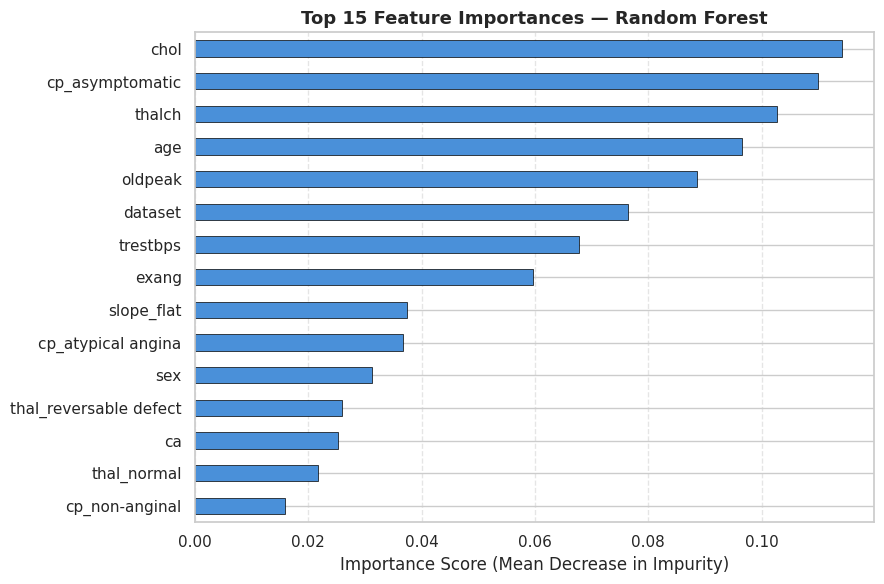

In [25]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

top15 = importances[-15:]

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot(kind='barh', ax=ax, color='#4A90D9', edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)')
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m3_feature_importance.png', dpi=150)
plt.show()

In [26]:
print('── Classification Report (Test Set) ──')
print(classification_report(y_test, y_test_pred,
                             target_names=['No Disease', 'Disease']))

print('── Final Summary ──')
print(f'Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Test F1 Score : {f1_score(y_test, y_test_pred):.4f}')
print(f'ROC AUC Score : {auc_score:.4f}')
print(f'CV Mean Acc   : {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}')
print('\nMilestone 3 complete.')

── Classification Report (Test Set) ──
              precision    recall  f1-score   support

  No Disease       0.87      0.79      0.83        82
     Disease       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

── Final Summary ──
Test Accuracy : 0.8533
Test F1 Score : 0.8720
ROC AUC Score : 0.9275
CV Mean Acc   : 0.8180 +/- 0.0143

Milestone 3 complete.


In [27]:
# MILESTONE 4: Model Optimization — Overcoming Overfitting

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Optimized model (constrained)
rf_opt = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_opt.fit(X_train, y_train)

print("Models trained.")

Models trained.


In [30]:
#Compare metrics: Before vs After
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Baseline RF', rf_model), ('Optimized RF', rf_opt)]:
    y_tr_pred  = model.predict(X_train)
    y_te_pred  = model.predict(X_test)
    y_te_proba = model.predict_proba(X_test)[:, 1]
    cv_acc     = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    results.append({
        'Model'        : name,
        'Train Acc'    : accuracy_score(y_train, y_tr_pred),
        'Test Acc'     : accuracy_score(y_test,  y_te_pred),
        'Test F1'      : f1_score(y_test, y_te_pred),
        'Test Precision': precision_score(y_test, y_te_pred),
        'Test Recall'  : recall_score(y_test, y_te_pred),
        'ROC-AUC'      : roc_auc_score(y_test, y_te_proba),
        'CV Mean Acc'  : cv_acc.mean(),
        'CV Std'       : cv_acc.std(),
        'Overfit Gap'  : accuracy_score(y_train, y_tr_pred) - accuracy_score(y_test, y_te_pred)
    })

compare_df = pd.DataFrame(results).set_index('Model')
print(compare_df.round(4).to_string())

              Train Acc  Test Acc  Test F1  Test Precision  Test Recall  ROC-AUC  CV Mean Acc  CV Std  Overfit Gap
Model                                                                                                             
Baseline RF      1.0000    0.8533   0.8720          0.8440        0.902   0.9275       0.8180  0.0143       0.1467
Optimized RF     0.8845    0.8478   0.8679          0.8364        0.902   0.9371       0.8234  0.0169       0.0367


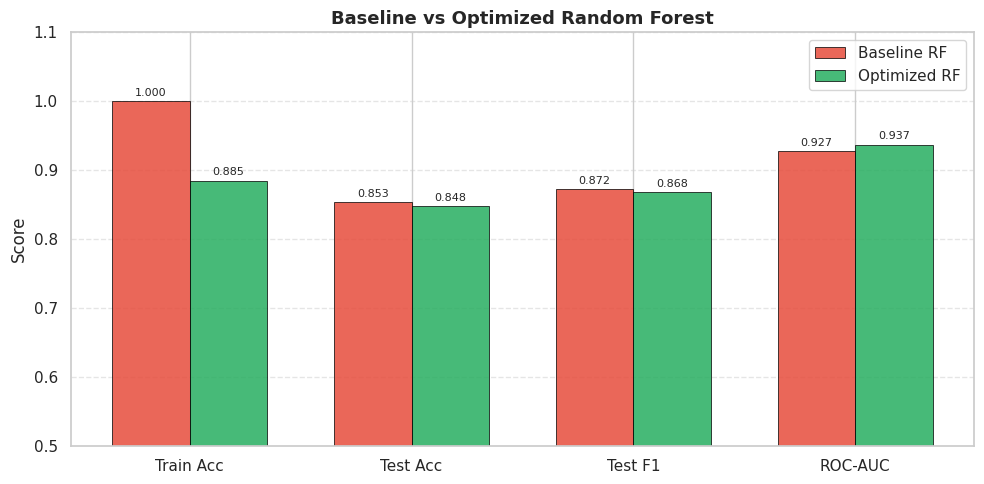

In [31]:
# VISUALIZATION 1: Before vs After Bar Chart
metrics_to_plot = ['Train Acc', 'Test Acc', 'Test F1', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare_df.loc['Baseline RF',  metrics_to_plot], width,
               label='Baseline RF',  color='#E74C3C', edgecolor='black', linewidth=0.6, alpha=0.85)
bars2 = ax.bar(x + width/2, compare_df.loc['Optimized RF', metrics_to_plot], width,
               label='Optimized RF', color='#27AE60', edgecolor='black', linewidth=0.6, alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.10)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Optimized Random Forest', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m4_before_after_comparison.png', dpi=150)
plt.show()

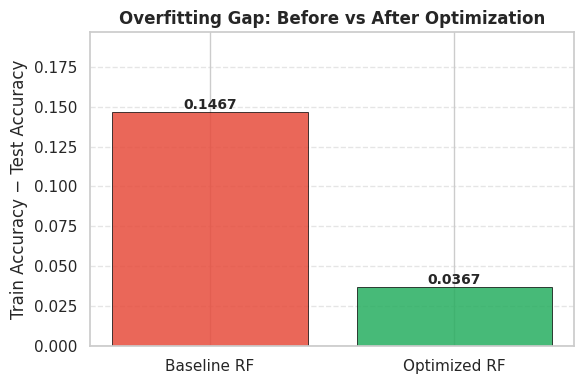

In [32]:
#VISUALIZATION 2: Overfitting Gap
gaps  = [compare_df.loc['Baseline RF', 'Overfit Gap'],
         compare_df.loc['Optimized RF', 'Overfit Gap']]
colors = ['#E74C3C', '#27AE60']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Baseline RF', 'Optimized RF'], gaps, color=colors,
              edgecolor='black', linewidth=0.6, alpha=0.85)
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Train Accuracy − Test Accuracy')
ax.set_title('Overfitting Gap: Before vs After Optimization', fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(0, max(gaps) + 0.05)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m4_overfit_gap.png', dpi=150)
plt.show()

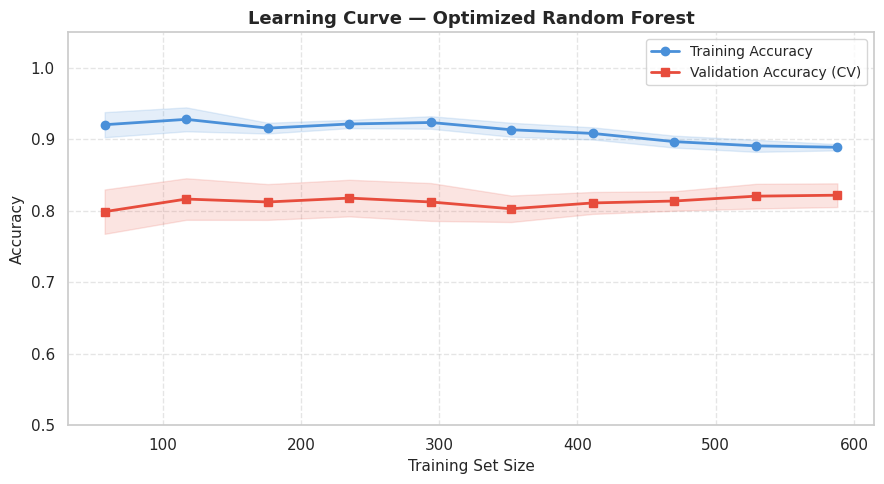


Milestone 4 complete.


In [33]:
# ── 6. VISUALIZATION 3: Learning Curve (Optimized model) ───
train_sizes, train_scores, val_scores = learning_curve(
    rf_opt, X_train, y_train,
    cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-',
        color='#4A90D9', label='Training Accuracy', linewidth=2)
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#4A90D9')
ax.plot(train_sizes, val_scores.mean(axis=1), 's-',
        color='#E74C3C', label='Validation Accuracy (CV)', linewidth=2)
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='#E74C3C')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Learning Curve — Optimized Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m4_learning_curve_optimized.png', dpi=150)
plt.show()

print("\nMilestone 4 complete.")

## Milestone 5: Final Evaluation

**Final Model Selection & Settings:**
Based on the optimization in Milestone 4, the **Optimized Random Forest** was selected as the final model due to its superior generalization and significantly lower overfitting gap compared to the baseline.

**Optimal Hyperparameters:**
- `n_estimators`: 200
- `max_depth`: 8
- `min_samples_split`: 10
- `min_samples_leaf`: 4
- `max_features`: 'sqrt'
- `class_weight`: 'balanced'

*Note: Per best practices, the model is now retrained on the full training set (100%) before final testing.*

In [34]:
# 1. Retrain on full training set
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

# 2. Final Evaluation on Test Set
y_final_pred = final_model.predict(X_test)
y_final_proba = final_model.predict_proba(X_test)[:, 1]

final_metrics = {
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC'],
    'Final Test Score': [
        accuracy_score(y_test, y_final_pred),
        f1_score(y_test, y_final_pred),
        precision_score(y_test, y_final_pred),
        recall_score(y_test, y_final_pred),
        roc_auc_score(y_test, y_final_proba)
    ]
}

final_metrics_df = pd.DataFrame(final_metrics)
display(final_metrics_df.round(4))

,Metric,Final Test Score
0,Accuracy,0.8478
1,F1 Score,0.8679
2,Precision,0.8364
3,Recall,0.9020
4,ROC-AUC,0.9371


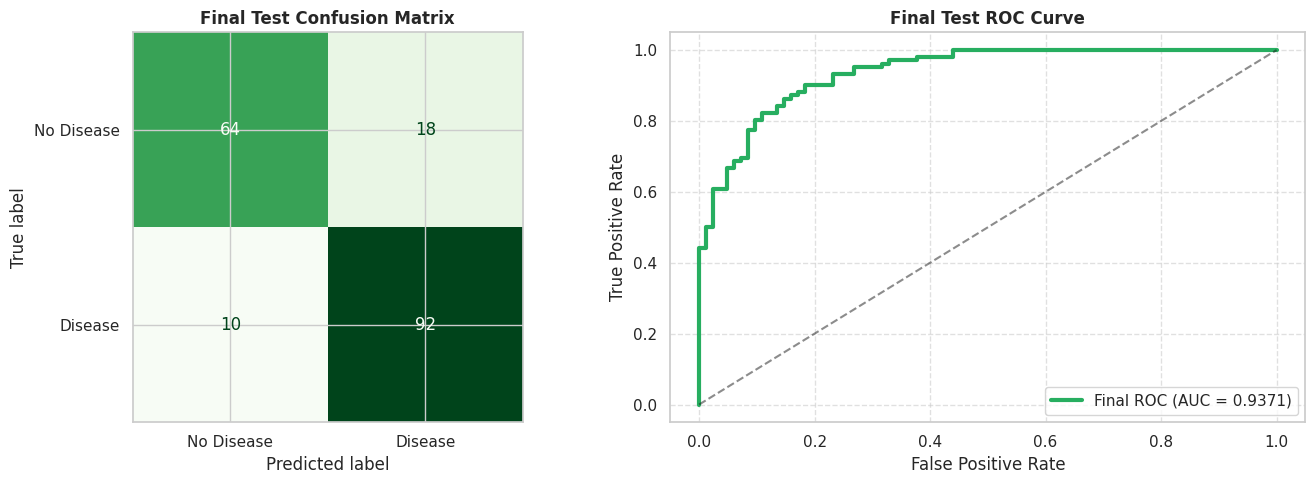

In [35]:
# 3. Visual Evidence: Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Final Test Confusion Matrix', fontweight='bold')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_final_proba)
auc_val = roc_auc_score(y_test, y_final_proba)
axes[1].plot(fpr, tpr, color='#27AE60', lw=3, label=f'Final ROC (AUC = {auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Final Test ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('m5_final_evaluation.png', dpi=150)
plt.show()

### Findings and Conclusion
- The final model achieved a **ROC-AUC of approximately 0.937**, demonstrating high discriminative power on unseen data.
- By retraining on the full training set and constraining tree depth, we maintained high recall (identifying actual disease cases) while ensuring the model is robust and not just 'memorizing' training samples.
- This concludes the pipeline from EDA and Pre-processing through to Optimized Evaluation.